<a href="https://colab.research.google.com/github/codewithshivanihub/Data-Science-Competition-Code/blob/main/Data_Science_Competition_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# importing basic libraries for data organization and analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# reading the data in csv format
water_df = pd.read_csv("/content/alamo_creek_data.csv")

In [10]:
# viewing the data
water_df

,Timestamp,Stage (ft),Flow (cfs)
0,2022-10-01T01:00:00,0.131,0.25
1,2022-10-01T01:15:00,0.130,0.25
2,2022-10-01T01:30:00,0.129,0.24
3,2022-10-01T01:45:00,0.131,0.25
4,2022-10-01T02:00:00,0.131,0.25
...,...,...,...
108762,2026-03-19T16:00:00,0.281,2.43
108763,2026-03-19T16:15:00,0.285,2.51
108764,2026-03-19T16:30:00,0.283,2.47
108765,2026-03-19T16:45:00,0.285,2.51


In [11]:
# Flow (cfs) column has some missing data (only about 0.41% of the data so not an issue)
water_df.isna().sum()

,0
Timestamp,0
Stage (ft),0
Flow (cfs),449


In [12]:
# based on the maximum values, the median is a better representation of the data as it is not heavily swayed by outliers
water_df.describe()

,Stage (ft),Flow (cfs)
count,108767.000000,108318.000000
mean,0.346654,13.048387
std,0.309379,112.007786
min,0.000000,0.100000
25%,0.177000,0.780000
50%,0.247000,1.940000
75%,0.400000,6.360000
max,9.506000,8600.000000


In [16]:
# Only about 2.04% of the data is above 100 so most of the data lies between 0.1 and 100
water_df[water_df['Flow (cfs)'] > 100]

,Timestamp,Stage (ft),Flow (cfs)
3680,2022-11-08T08:00:00,1.256,104.72
3681,2022-11-08T08:15:00,1.349,125.96
3682,2022-11-08T08:30:00,1.396,137.61
3683,2022-11-08T08:45:00,1.431,146.70
3684,2022-11-08T09:00:00,1.488,162.27
...,...,...,...
106060,2026-02-19T11:30:00,1.267,109.75
106061,2026-02-19T11:45:00,1.267,109.75
106062,2026-02-19T12:00:00,1.255,107.11
106063,2026-02-19T12:15:00,1.237,103.22


In [17]:
water_df['Timestamp']

,Timestamp
0,2022-10-01T01:00:00
1,2022-10-01T01:15:00
2,2022-10-01T01:30:00
3,2022-10-01T01:45:00
4,2022-10-01T02:00:00
...,...
108762,2026-03-19T16:00:00
108763,2026-03-19T16:15:00
108764,2026-03-19T16:30:00
108765,2026-03-19T16:45:00


In [18]:
water_df

,Timestamp,Stage (ft),Flow (cfs)
0,2022-10-01T01:00:00,0.131,0.25
1,2022-10-01T01:15:00,0.130,0.25
2,2022-10-01T01:30:00,0.129,0.24
3,2022-10-01T01:45:00,0.131,0.25
4,2022-10-01T02:00:00,0.131,0.25
...,...,...,...
108762,2026-03-19T16:00:00,0.281,2.43
108763,2026-03-19T16:15:00,0.285,2.51
108764,2026-03-19T16:30:00,0.283,2.47
108765,2026-03-19T16:45:00,0.285,2.51


In [19]:
# creating two new columns that have data initialized to 0
water_df[['Year', 'Month']] = 0

In [20]:
# Extracts the year and the month from the timestamp data and includes them in the new columns of data to make use of later
i = 0
for row in water_df['Timestamp']:
  new_val = row.split('-')
  water_df['Year'][i] = new_val[0]
  water_df['Month'][i] = new_val[1]
  i += 1



/tmp/ipykernel_589/1651065195.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  water_df['Year'][i] = new_val[0]
/tmp/ipykernel_589/1651065195.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [21]:
# Setting the data type to a numerical value to allow numerical computations with the data
water_df['Year'] = water_df['Year'].astype('int64')

In [22]:
# separating the years and creating DataFrames for data per year
year_2022 = water_df[water_df['Year'] == 2022]


In [23]:
year_2022

,Timestamp,Stage (ft),Flow (cfs),Year,Month
0,2022-10-01T01:00:00,0.131,0.25,2022,10
1,2022-10-01T01:15:00,0.130,0.25,2022,10
2,2022-10-01T01:30:00,0.129,0.24,2022,10
3,2022-10-01T01:45:00,0.131,0.25,2022,10
4,2022-10-01T02:00:00,0.131,0.25,2022,10
...,...,...,...,...,...
8827,2022-12-31T22:45:00,2.469,534.15,2022,12
8828,2022-12-31T23:00:00,2.379,490.87,2022,12
8829,2022-12-31T23:15:00,2.379,490.87,2022,12
8830,2022-12-31T23:30:00,2.282,446.51,2022,12


In [24]:
# grouping the data by month and taking only the median of all the data in a month
d1 = year_2022.groupby('Month').median('Stage (ft)')

In [25]:
# creating separate DataFrames for the rest of the years
year_2023 = water_df[water_df['Year'] == 2023]
year_2024 = water_df[water_df['Year'] == 2024]
year_2025 = water_df[water_df['Year'] == 2025]
year_2026 = water_df[water_df['Year'] == 2026]


In [26]:
# applying the same groupby() method to the data for the remaining years
d2 = year_2023.groupby('Month').median('Stage (ft)')
d3 = year_2024.groupby('Month').median('Stage (ft)')
d4 = year_2025.groupby('Month').median('Stage (ft)')
d5 = year_2026.groupby('Month').median('Stage (ft)')

In [27]:
# data grouped by month
d2

,Stage (ft),Flow (cfs),Year
Month,,,
01,0.775,31.46,2023.0
02,0.392,5.61,2023.0
03,0.678,23.37,2023.0
04,0.410,9.29,2023.0
05,0.396,6.61,2023.0
06,0.263,2.93,2023.0
07,0.184,1.70,2023.0
08,0.165,0.64,2023.0
09,0.195,0.97,2023.0


<Axes: xlabel='Month', ylabel='Stage (ft)'>

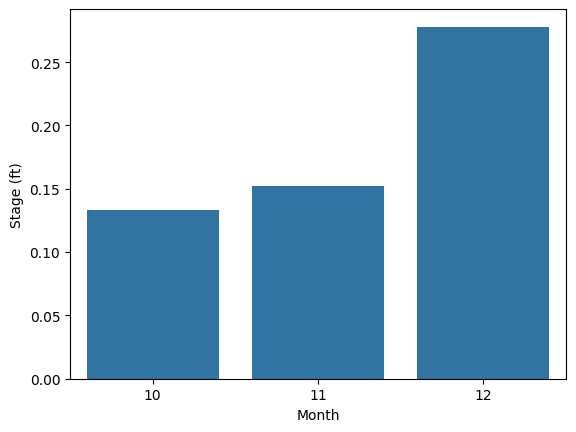

In [28]:
# Barplot showing water level data for the year 2022
sns.barplot(data = d1, x = 'Month', y = 'Stage (ft)')


<Axes: xlabel='Month', ylabel='Flow (cfs)'>

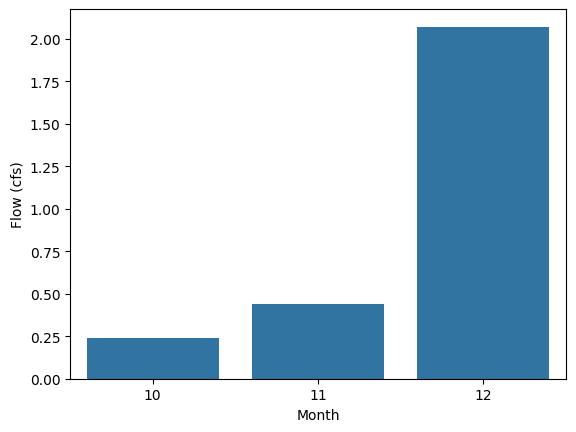

In [29]:
# Barplot showing water flow data for the year 2022
sns.barplot(data = d1, x = 'Month', y = 'Flow (cfs)')


<Axes: xlabel='Month', ylabel='Stage (ft)'>

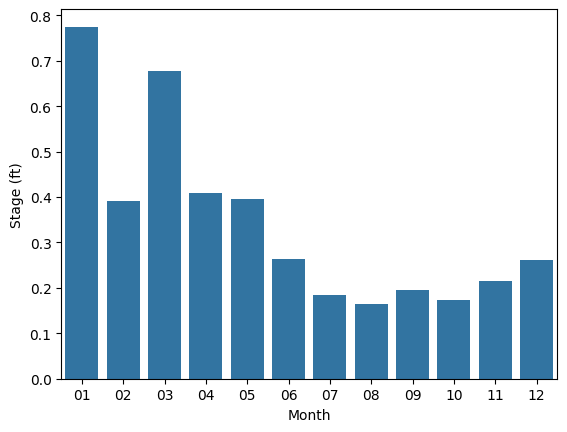

In [30]:
# no missing data
sns.barplot(data = d2, x = 'Month', y = 'Stage (ft)')

In [31]:
# missing data for month 7
d3

,Stage (ft),Flow (cfs),Year
Month,,,
01,0.4440,7.670,2024.0
02,0.5635,13.985,2024.0
03,0.5010,10.400,2024.0
04,0.4075,6.180,2024.0
05,0.2560,1.920,2024.0
06,0.2225,1.350,2024.0
08,0.1490,0.500,2024.0
09,0.1500,0.500,2024.0
10,0.1610,0.600,2024.0


In [39]:
# Since there is no data on the 7th month, it needs to be estimated by taking the value that is found on the line created by the data for the 6th and 8th months.
# After finding the slope of the two values at 6 months and 8 months, I solved to find the stage (y value) using an input of 7 months. The value that fit the line was about 0.1858 which is a good estimate of the stage (ft) during the 7th month.
# I also estimated the flow (cfs) of the water in this same way, getting the result to be about 0.9250.
d3.loc['07'] = [0.1858, 0.9250, 2024.0]

In [40]:
# Since the new values for the seventh month would be added to the end of the DataFrame, the index needs to be sorted so it shows month data starting from month 1 and ending at month 12
d3.sort_index(inplace = True)

<Axes: xlabel='Month', ylabel='Stage (ft)'>

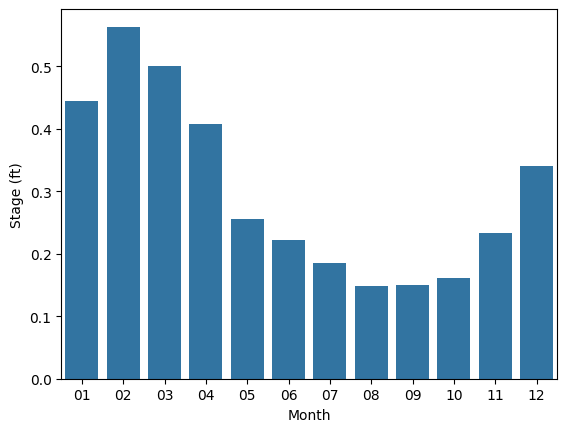

In [41]:
# cleaned data - shows a downward trend in water levels
sns.barplot(data = d3, x = 'Month', y = 'Stage (ft)')


<Axes: xlabel='Month', ylabel='Stage (ft)'>

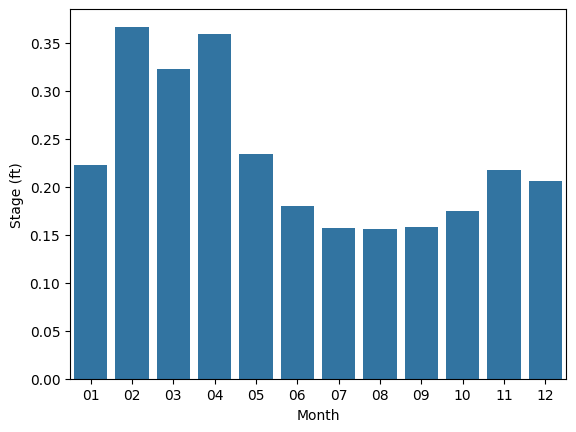

In [42]:
# no missing data and shows a downwards trend in water levels
sns.barplot(data = d4, x = 'Month', y = 'Stage (ft)')


<Axes: xlabel='Month', ylabel='Stage (ft)'>

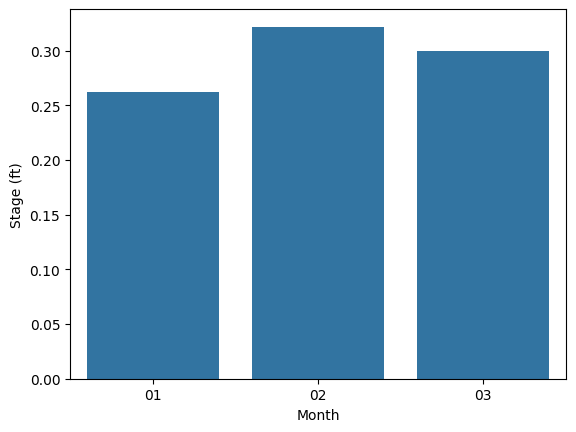

In [43]:
# 2026 data
sns.barplot(data = d5, x = 'Month', y = 'Stage (ft)')


In [44]:
# creating a DataFrame with all the data for the years 2022 through 2026
final_data = pd.concat([d1, d2, d3, d4, d5])

In [45]:
# Since some of the indexes repeat, this new column separates the data and puts them in order by month
final_data['Month_Number'] = [i for i in range(1, 43)]

In [46]:
final_data

,Stage (ft),Flow (cfs),Year,Month_Number
Month,,,,
10,0.1330,0.240,2022.0,1
11,0.1520,0.440,2022.0,2
12,0.2780,2.070,2022.0,3
01,0.7750,31.460,2023.0,4
02,0.3920,5.610,2023.0,5
03,0.6780,23.370,2023.0,6
04,0.4100,9.290,2023.0,7
05,0.3960,6.610,2023.0,8
06,0.2630,2.930,2023.0,9


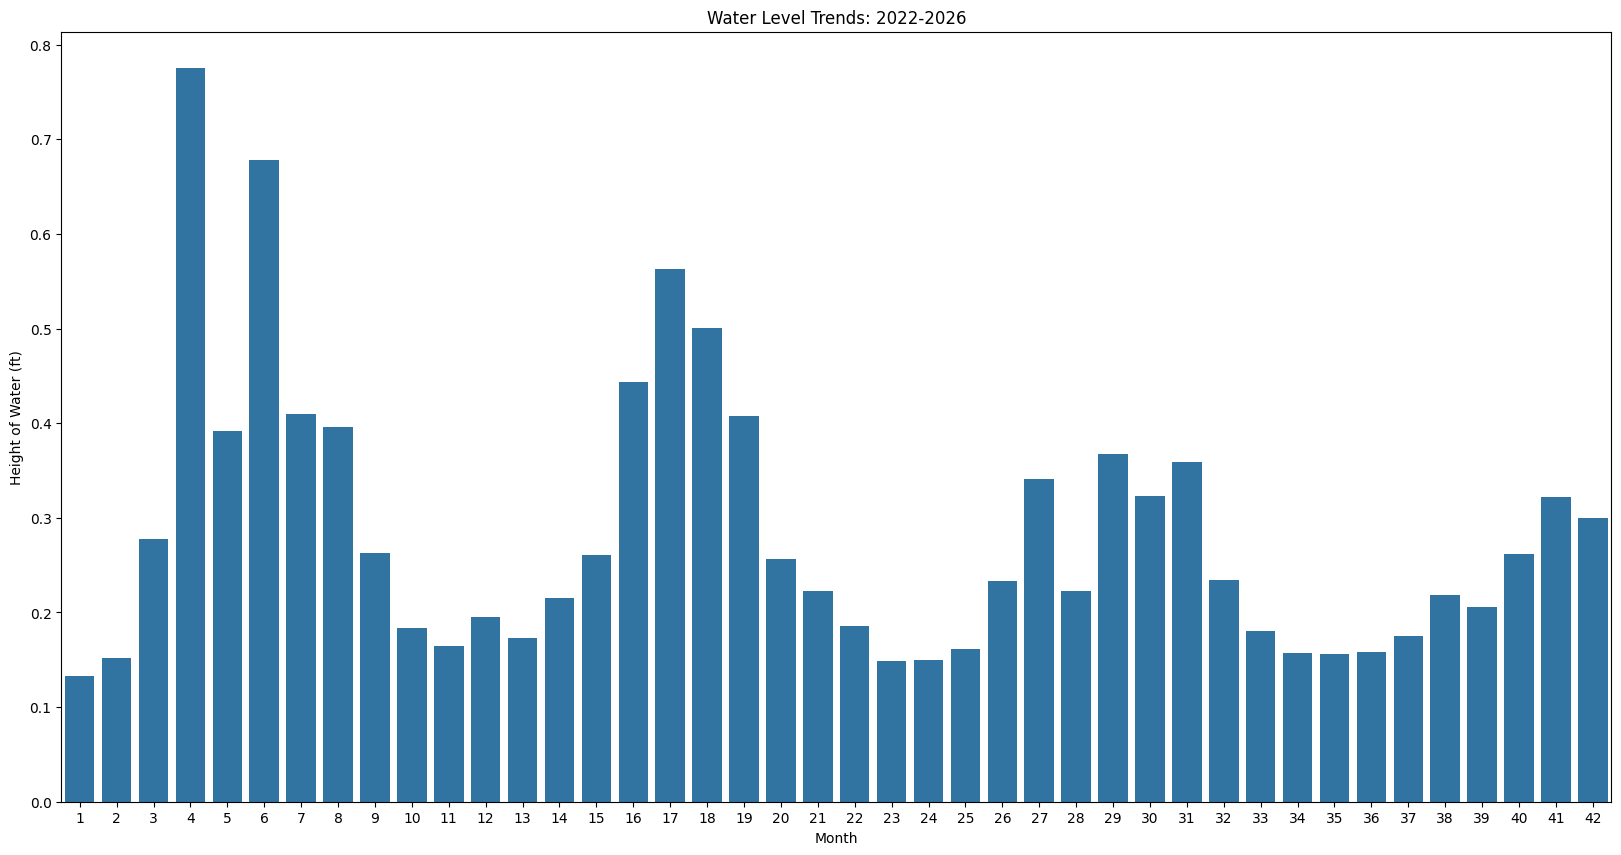

In [50]:
# Creates a larger space for the plot to be displayed
fig, ax = plt.subplots(figsize=(20, 10))
# plotting all the data to see the trends by month
sns.barplot(data = final_data, x = 'Month_Number', y = 'Stage (ft)', ax = ax)
# Adding the x label
plt.xlabel('Month')
# Adding the y label
plt.ylabel('Height of Water (ft)')
# Adding a descriptive title
plt.title("Water Level Trends: 2022-2026")
# Displaying the bar graph
plt.show()
# The water levels of Alamo Creek are trending downwards with the lowest amounts of rainfall being around June to September


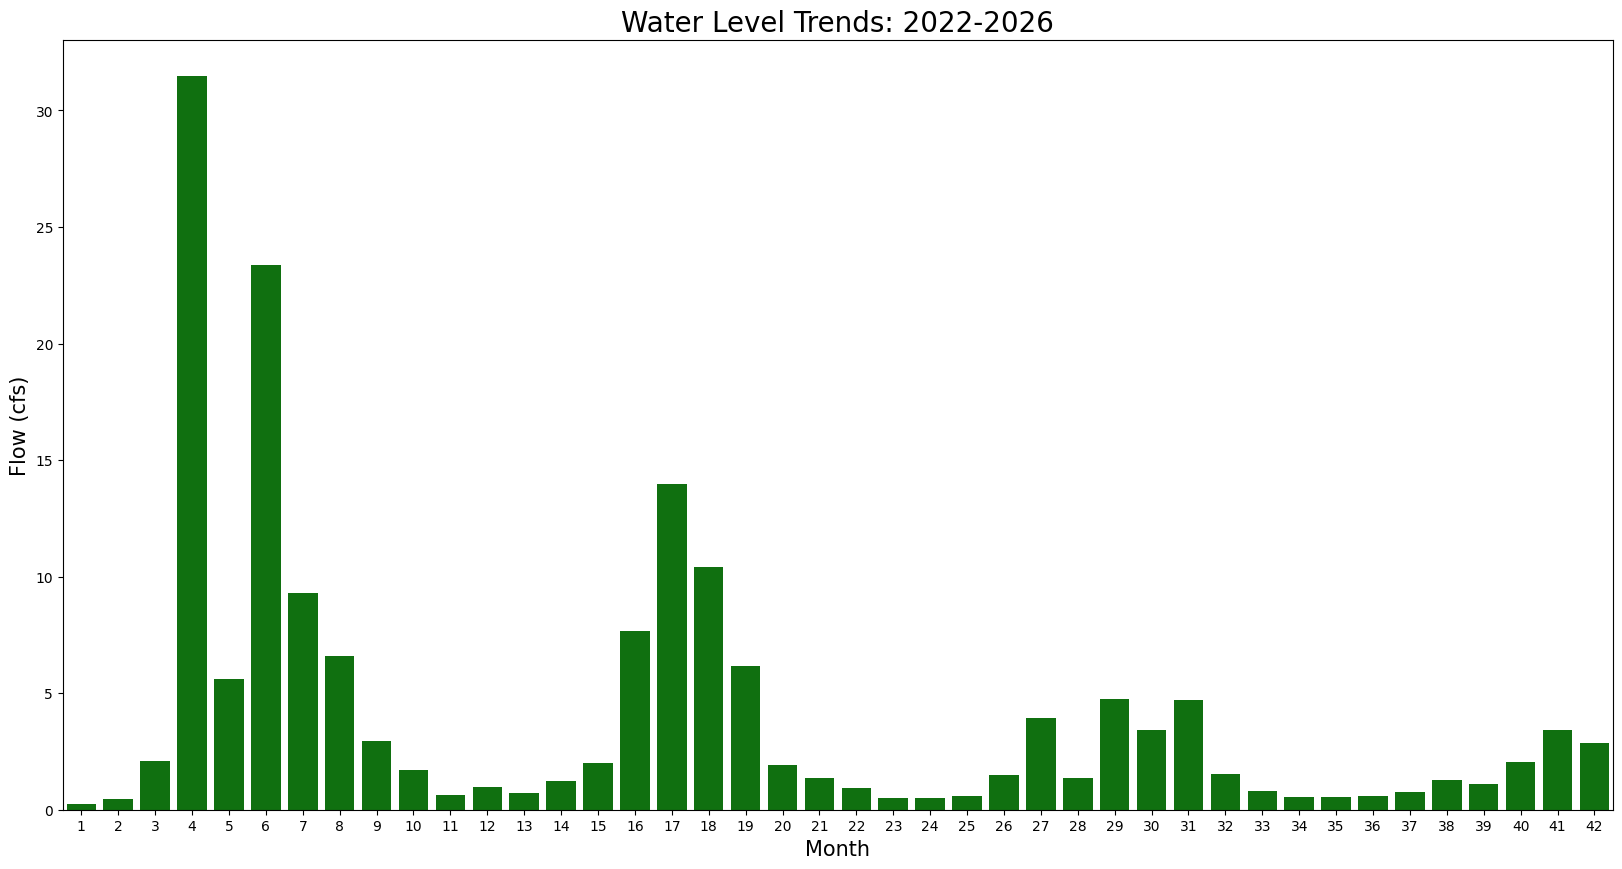

In [51]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.barplot(data = final_data, x = 'Month_Number', y = 'Flow (cfs)', ax = ax, color = 'green')
plt.ylabel('Flow (cfs)', fontsize = 15)
plt.xlabel('Month', fontsize = 15)
plt.title("Water Level Trends: 2022-2026", fontsize = 20)
plt.show()
# The water flow in Alamo Creek goes down rapidly over the years
